# Force-4 Flight Data Plotter

Plots acceleration data from a Force-4 CSV flight file.

## Setup

```bash
# Create and activate a virtual environment
python3 -m venv .venv
source .venv/bin/activate

# Install dependencies
pip install -r requirements.txt

# Launch Jupyter
jupyter notebook plot_flight.ipynb
```

## Download flight data

```bash
# Download the most recent flight
./data.sh pull

# Or download a specific file
./data.sh pull flight_000.csv
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

In [33]:
# --- Config ---
CSV_FILE = "flight_014.csv"  # change to the flight file you want to plot

df = pd.read_csv(CSV_FILE)
df["t_s"] = (df["timestamp_ns"] - df["timestamp_ns"].iloc[0]) / 1e9
df["mag_g"] = np.sqrt(df["ax_g"]**2 + df["ay_g"]**2 + df["az_g"]**2)

print(f"File:     {CSV_FILE}")
print(f"Samples:  {len(df)}")
print(f"Duration: {df['t_s'].iloc[-1]:.2f} s")
print(f"Avg rate: {len(df) / df['t_s'].iloc[-1]:.0f} Hz")
print(f"Peak |a|: {df['mag_g'].max():.2f} g  at t={df.loc[df['mag_g'].idxmax(), 't_s']:.3f} s")
df.head(3)

File:     flight_014.csv
Samples:  46755
Duration: 60.19 s
Avg rate: 777 Hz
Peak |a|: 53.14 g  at t=7.453 s


,timestamp_ns,ax_g,ay_g,az_g,t_s,mag_g
0,10070797000,0.392,0.098,0.392,0.00000,0.562967
1,10072047000,0.441,-0.049,0.490,0.00125,0.661046
2,10073297000,0.686,-0.147,0.637,0.00250,0.947615


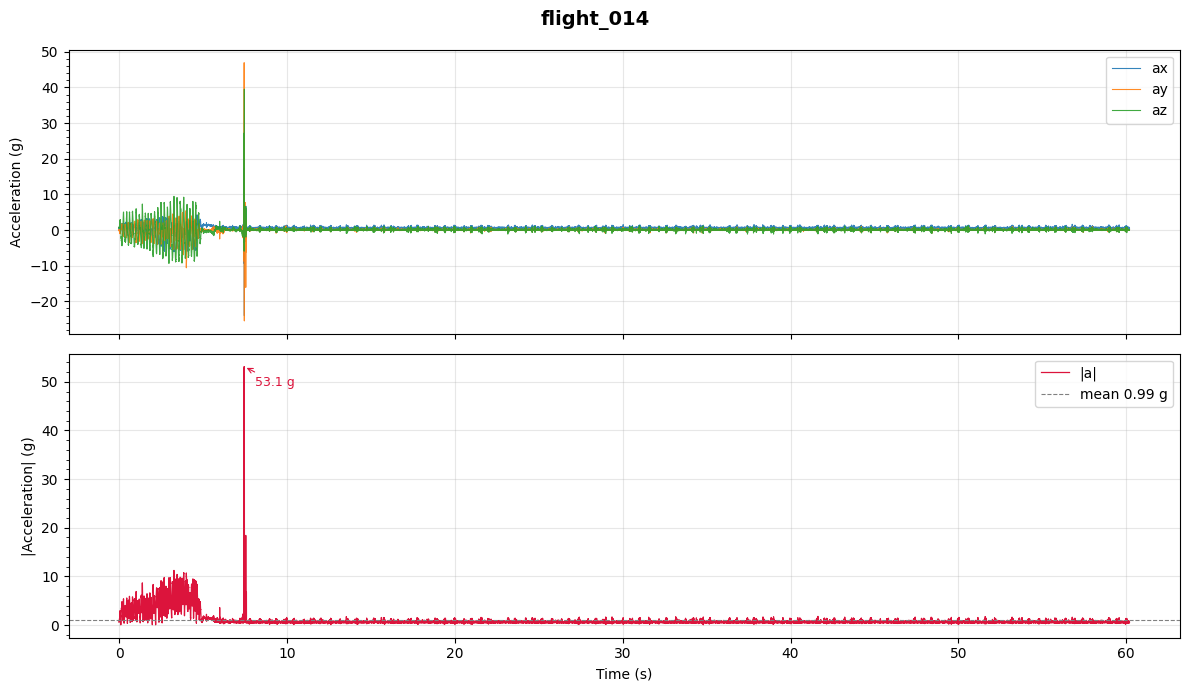

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle(Path(CSV_FILE).stem, fontsize=14, fontweight="bold")

# --- Axes subplot ---
ax = axes[0]
ax.plot(df["t_s"], df["ax_g"], label="ax", linewidth=0.8, alpha=0.9)
ax.plot(df["t_s"], df["ay_g"], label="ay", linewidth=0.8, alpha=0.9)
ax.plot(df["t_s"], df["az_g"], label="az", linewidth=0.8, alpha=0.9)
ax.set_ylabel("Acceleration (g)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# --- Magnitude subplot ---
ax2 = axes[1]
ax2.plot(df["t_s"], df["mag_g"], color="crimson", linewidth=0.9, label="|a|")
ax2.axhline(df["mag_g"].mean(), color="gray", linestyle="--", linewidth=0.8, label=f"mean {df['mag_g'].mean():.2f} g")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("|Acceleration| (g)")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Mark peak
peak_idx = df["mag_g"].idxmax()
ax2.annotate(
    f"{df.loc[peak_idx, 'mag_g']:.1f} g",
    xy=(df.loc[peak_idx, "t_s"], df.loc[peak_idx, "mag_g"]),
    xytext=(8, -14), textcoords="offset points",
    fontsize=9, color="crimson",
    arrowprops=dict(arrowstyle="->", color="crimson", lw=0.8),
)

plt.tight_layout()
plt.show()